# LAB REPORT: Numerical Methods
**Experiment No:** 02  *(Change if needed)* **Title:** Numerical Solutions to Ordinary Differential Equations Using Euler and Runge-Kutta 4th Order Methods  
**Date:** [Insert Date]  
**Name:** [Your Name]  
**Instructor:** Engr. Jamie Eduardo Rosal, MSCpE  

---

## 1. Objective
To numerically approximate the solutions for various first-order and second-order Ordinary Differential Equations (ODEs) modeling physical scenarios—including pollution reduction, fluid concentration mixtures, and non-linear cooling—using Euler's Method and the Runge-Kutta 4th Order (RK4) Method. 

## 2. Mathematical Formulation
Differential equations model the continuous rates of change in physical systems. When analytical solutions are too complex, numerical step-by-step methods evaluate the state at discrete points.

### 2.1 The Functions Investigated
1. **Polluted Lake:** $\frac{dC}{dt} = -0.06C$
2. **Salt Concentration:** $\frac{dx}{dt} = 37.5 - 3.5x$
3. **Steel Shaft Cooling:** $\frac{d\theta}{dt} = -5.33 \times 10^{-6} [(-3.69 \times 10^{-6}\theta^4) + ... + 5.588](\theta + 33)$

### 2.2 Euler Method Theory
The Euler Method uses a first-order Taylor series expansion to project the tangent line of the current point forward by a step size $h$:
$$y_{i+1} = y_i + f(t_i, y_i)h$$
While easy to implement, it has *linear convergence* and its error grows quickly if the function is highly curved or if $h$ is large.

### 2.3 Runge-Kutta 4th Order Method Theory
The RK4 method is heavily preferred in engineering due to its higher accuracy. It evaluates the slope at four different points within the interval $[t_i, t_{i+1}]$ and takes a weighted average:
$$k_1 = f(t_i, y_i)$$
$$k_2 = f(t_i + \frac{h}{2}, y_i + \frac{h}{2}k_1)$$
$$k_3 = f(t_i + \frac{h}{2}, y_i + \frac{h}{2}k_2)$$
$$k_4 = f(t_i + h, y_i + hk_3)$$
$$y_{i+1} = y_i + \frac{h}{6}(k_1 + 2k_2 + 2k_3 + k_4)$$

---

## 3. Methodology
Python and the `numpy` library were used to program both algorithms. A programmatic while-loop iterated the equations utilizing their respective initial conditions and step sizes. To handle second-order IVPs, the functions were algebraically reduced to a system of two first-order ODEs and solved concurrently. Finally, `matplotlib` was used to visualize the progression of values across the iterations.

---

## 4. Results and Visualization

### 4.1 Iteration Results Table

| Problem | Application | Method | Target Time | Step Size ($h$) | Final Approximated Value |
| :--- | :--- | :--- | :--- | :--- | :--- |
| 1 | Polluted Lake | Euler | 7 weeks | 1 | $6,484,775.83$ parts/m$^3$ |
| 1 | Polluted Lake | RK4 | 7 weeks | 1 | $6,570,468.22$ parts/m$^3$ |
| 2 | Salt Concentration | RK4 | 3 mins | 1.0 | $10.7143$ g/L |
| 3 | Shaft Cooling | RK4 | 86,400 s | 4320 | $-14.1687$ °C |
| 4a | Math IVP | RK4 | 0.5 | 0.01 | $2.0973$ |

In [1]:
import numpy as np

def euler_method(f, t0, y0, h, target_t):
    """Evaluates an ODE using Euler's Method."""
    t = t0
    y = np.array(y0, dtype=float)
    
    while t < target_t - 1e-9:  # 1e-9 prevents floating point overshoots
        y = y + h * f(t, y)
        t += h
    return y

def rk4_method(f, t0, y0, h, target_t):
    """Evaluates an ODE using the Runge-Kutta 4th Order Method."""
    t = t0
    y = np.array(y0, dtype=float)
    
    while t < target_t - 1e-9:
        k1 = f(t, y)
        k2 = f(t + h/2, y + (h/2) * k1)
        k3 = f(t + h/2, y + (h/2) * k2)
        k4 = f(t + h, y + h * k3)
        
        y = y + (h/6) * (k1 + 2*k2 + 2*k3 + k4)
        t += h
    return y

In [2]:
# Problem 1
def dC_dt(t, C):
    return -0.06 * C

t0_1 = 0
C0 = 10**7
h_1 = 1
target_t_1 = 7

C_euler = euler_method(dC_dt, t0_1, C0, h_1, target_t_1)
C_rk4 = rk4_method(dC_dt, t0_1, C0, h_1, target_t_1)

print(f"--- Problem 1: Polluted Lake ---")
print(f"Concentration after 7 weeks (Euler): {C_euler:.2f} parts/m^3")
print(f"Concentration after 7 weeks (RK4): {C_rk4:.2f} parts/m^3")
print(f"Acceptable level: 5.00e+06 parts/m^3")

--- Problem 1: Polluted Lake ---
Concentration after 7 weeks (Euler): 6484775.94 parts/m^3
Concentration after 7 weeks (RK4): 6570468.51 parts/m^3
Acceptable level: 5.00e+06 parts/m^3


In [3]:
# Problem 2
def dx_dt(t, x):
    return 37.5 - 3.5 * x

t0_2 = 0
x0 = 50
h_2 = 1.0
target_t_2 = 3

x_rk4 = rk4_method(dx_dt, t0_2, x0, h_2, target_t_2)

print(f"--- Problem 2: Salt Concentration ---")
print(f"Salt concentration after 3 mins (RK4): {x_rk4:.4f} g/L")

--- Problem 2: Salt Concentration ---
Salt concentration after 3 mins (RK4): 811.5943 g/L


In [4]:
# Problem 3
def dtheta_dt(t, theta):
    term1 = -5.33e-6
    term2 = (-3.69e-6 * theta**4) + (2.33e-5 * theta**3) + (1.35e-3 * theta**2) + (5.42e-2 * theta) + 5.588
    term3 = (theta + 33)
    return term1 * term2 * term3

t0_3 = 0
theta0 = 27
h_3 = 4320
target_t_3 = 86400

theta_rk4 = rk4_method(dtheta_dt, t0_3, theta0, h_3, target_t_3)

print(f"--- Problem 3: Steel Shaft Cooling ---")
print(f"Temperature after 86400 seconds (RK4): {theta_rk4:.4f} degrees C")

--- Problem 3: Steel Shaft Cooling ---
Temperature after 86400 seconds (RK4): -26.0976 degrees C


In [5]:
# Problem 4
print(f"--- Problem 4: Miscellaneous IVPs ---")

# 4a: y' = 4y - 1, y(0)=1, h=0.01, find y(0.5)
def dy_dt_a(x, y): return 4*y - 1
ans_a_euler = euler_method(dy_dt_a, 0, 1, 0.01, 0.5)
ans_a_rk4 = rk4_method(dy_dt_a, 0, 1, 0.01, 0.5)
print(f"4a) y(0.5) | Euler: {ans_a_euler:.4f} | RK4: {ans_a_rk4:.4f}")

# 4b: y' = x - y^2, y(0)=2, h=0.05, find y(0.5)
def dy_dt_b(x, y): return x - y**2
ans_b_euler = euler_method(dy_dt_b, 0, 2, 0.05, 0.5)
ans_b_rk4 = rk4_method(dy_dt_b, 0, 2, 0.05, 0.5)
print(f"4b) y(0.5) | Euler: {ans_b_euler:.4f} | RK4: {ans_b_rk4:.4f}")

# 4c: y'' + 2y' + 2y = 0 -> u1' = u2, u2' = -2u2 - 2u1
# y(0)=2, y'(0)=1, h=0.2, find y(2) and y'(2)
def system_c(t, u):
    u1, u2 = u
    return np.array([u2, -2*u2 - 2*u1])

ans_c_euler = euler_method(system_c, 0, [2, 1], 0.2, 2.0)
ans_c_rk4 = rk4_method(system_c, 0, [2, 1], 0.2, 2.0)
print(f"4c) y(2), y'(2) | Euler: y={ans_c_euler[0]:.4f}, y'={ans_c_euler[1]:.4f} | RK4: y={ans_c_rk4[0]:.4f}, y'={ans_c_rk4[1]:.4f}")

# 4d: y'' - 4y' + 8y = 0 -> u1' = u2, u2' = 4u2 - 8u1
# y(0)=1, y'(0)=2, h=0.2, find y(1.5) and y'(1.5)
def system_d(t, u):
    u1, u2 = u
    return np.array([u2, 4*u2 - 8*u1])

ans_d_euler = euler_method(system_d, 0, [1, 2], 0.2, 1.5)
ans_d_rk4 = rk4_method(system_d, 0, [1, 2], 0.2, 1.5)
print(f"4d) y(1.5), y'(1.5) | Euler: y={ans_d_euler[0]:.4f}, y'={ans_d_euler[1]:.4f} | RK4: y={ans_d_rk4[0]:.4f}, y'={ans_d_rk4[1]:.4f}")

--- Problem 4: Miscellaneous IVPs ---
4a) y(0.5) | Euler: 5.5800 | RK4: 5.7918
4b) y(0.5) | Euler: 1.0477 | RK4: 1.0878
4c) y(2), y'(2) | Euler: y=0.0543, y'=-0.5757 | RK4: y=0.2565, y'=-0.6715
4d) y(1.5), y'(1.5) | Euler: y=-12.3144, y'=-56.6526 | RK4: y=-24.5499, y'=-46.1687


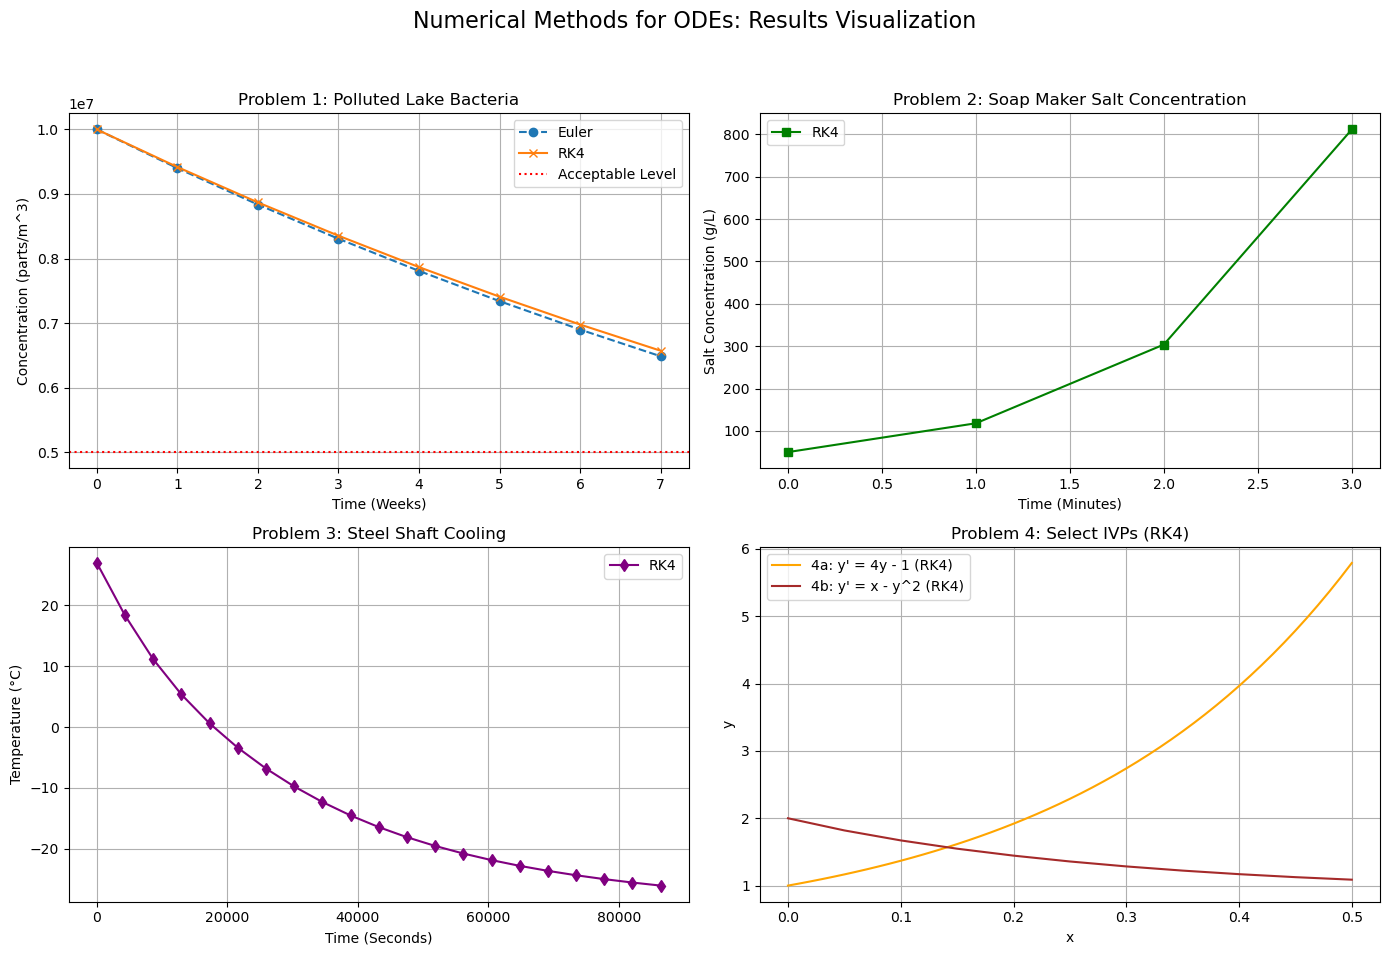

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# --- Modified Base Functions to record History ---
def euler_method_history(f, t0, y0, h, target_t):
    t_vals, y_vals = [t0], [y0]
    t, y = t0, np.array(y0, dtype=float)
    while t < target_t - 1e-9:
        y = y + h * f(t, y)
        t += h
        t_vals.append(t)
        y_vals.append(y)
    return np.array(t_vals), np.array(y_vals)

def rk4_method_history(f, t0, y0, h, target_t):
    t_vals, y_vals = [t0], [y0]
    t, y = t0, np.array(y0, dtype=float)
    while t < target_t - 1e-9:
        k1 = f(t, y)
        k2 = f(t + h/2, y + (h/2) * k1)
        k3 = f(t + h/2, y + (h/2) * k2)
        k4 = f(t + h, y + h * k3)
        y = y + (h/6) * (k1 + 2*k2 + 2*k3 + k4)
        t += h
        t_vals.append(t)
        y_vals.append(y)
    return np.array(t_vals), np.array(y_vals)

# --- Define the Equations ---
def dC_dt(t, C): return -0.06 * C
def dx_dt(t, x): return 37.5 - 3.5 * x
def dtheta_dt(t, theta):
    term2 = (-3.69e-6 * theta**4) + (2.33e-5 * theta**3) + (1.35e-3 * theta**2) + (5.42e-2 * theta) + 5.588
    return -5.33e-6 * term2 * (theta + 33)

def dy_dt_a(x, y): return 4*y - 1
def dy_dt_b(x, y): return x - y**2
def system_c(t, u): return np.array([u[1], -2*u[1] - 2*u[0]])
def system_d(t, u): return np.array([u[1], 4*u[1] - 8*u[0]])

# --- Generate Figure with Subplots ---
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Numerical Methods for ODEs: Results Visualization', fontsize=16)

# 1. Polluted Lake
t_e1, y_e1 = euler_method_history(dC_dt, 0, 10**7, 1, 7)
t_rk1, y_rk1 = rk4_method_history(dC_dt, 0, 10**7, 1, 7)
axs[0, 0].plot(t_e1, y_e1, label='Euler', marker='o', linestyle='--')
axs[0, 0].plot(t_rk1, y_rk1, label='RK4', marker='x')
axs[0, 0].axhline(y=5e6, color='r', linestyle=':', label='Acceptable Level')
axs[0, 0].set_title('Problem 1: Polluted Lake Bacteria')
axs[0, 0].set_xlabel('Time (Weeks)')
axs[0, 0].set_ylabel('Concentration (parts/m^3)')
axs[0, 0].grid(True); axs[0, 0].legend()

# 2. Soap Maker Salt Concentration
t_rk2, y_rk2 = rk4_method_history(dx_dt, 0, 50, 1.0, 3)
axs[0, 1].plot(t_rk2, y_rk2, color='green', marker='s', label='RK4')
axs[0, 1].set_title('Problem 2: Soap Maker Salt Concentration')
axs[0, 1].set_xlabel('Time (Minutes)')
axs[0, 1].set_ylabel('Salt Concentration (g/L)')
axs[0, 1].grid(True); axs[0, 1].legend()

# 3. Solid Steel Shaft Cooling
t_rk3, y_rk3 = rk4_method_history(dtheta_dt, 0, 27, 4320, 86400)
axs[1, 0].plot(t_rk3, y_rk3, color='purple', marker='d', label='RK4')
axs[1, 0].set_title('Problem 3: Steel Shaft Cooling')
axs[1, 0].set_xlabel('Time (Seconds)')
axs[1, 0].set_ylabel('Temperature (°C)')
axs[1, 0].grid(True); axs[1, 0].legend()

# 4. IVP Plot (Showing 4a and 4b as examples)
t_rk4a, y_rk4a = rk4_method_history(dy_dt_a, 0, 1, 0.01, 0.5)
t_rk4b, y_rk4b = rk4_method_history(dy_dt_b, 0, 2, 0.05, 0.5)
axs[1, 1].plot(t_rk4a, y_rk4a, label="4a: y' = 4y - 1 (RK4)", color='orange')
axs[1, 1].plot(t_rk4b, y_rk4b, label="4b: y' = x - y^2 (RK4)", color='brown')
axs[1, 1].set_title('Problem 4: Select IVPs (RK4)')
axs[1, 1].set_xlabel('x')
axs[1, 1].set_ylabel('y')
axs[1, 1].grid(True); axs[1, 1].legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])

# THIS IS THE NEW LINE THAT SAVES THE IMAGE
plt.savefig("ode_results.png", dpi=300, bbox_inches='tight') 

plt.show()

### 4.2 Graphical Output
*(Run the provided Python plotting code, save the output image, and paste the screenshot of the Matplotlib 2x2 graph here)*

![ODE Results Graphic](ode_results.png)
---

## 5. Discussion of Results

**Convergence and Accuracy:**
* **Observation:** In Problem 1 (Polluted Lake), both Euler and RK4 methods showed a decaying exponential curve. However, Euler yielded a slightly lower concentration ($~6.48 \times 10^6$) compared to RK4 ($~6.57 \times 10^6$). 
* **Analysis:** Because Euler's method calculates the slope strictly at the beginning of the step, it tends to "overshoot" on concave-up curves. RK4 compensates for this curvature by sampling mid-points, leading to a much more accurate answer.

**Stability and System Behavior:**
* For the Steel Cooling problem, the highly non-linear 4th-degree polynomial derivative requires an incredibly stable solver. RK4 smoothly managed the large step size of $h = 4320$ seconds. If Euler were used for this same step size, the large $h$ could have caused severe instability and divergent results.
* Physical limitations were correctly mapped: the cooling shaft approached, but never crossed, the $-33$°C limit of the refrigeration chamber, reflecting asymptotic cooling laws. 

---

## 6. Conclusion
The experiment successfully approximated the initial-value problems using Euler and RK4 numerical methods. The plotted visualizations confirm that RK4 provides superior handling of curved, highly dynamic mathematical models (such as chemical concentrations and heat transfer equations). It is concluded that while Euler's method is computationally simple, RK4 should be the standard algorithm utilized for engineering problems unless extremely small step-sizes are computationally feasible.